In [1]:
# ================================================================
# LAB 7: Fine-tuning BERT — CORRECT IMPORTS (Final)
# ================================================================

!pip install transformers datasets -q

import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW                          # ← only AdamW from torch.optim

from transformers import (                             # ← Bert classes from transformers
    BertTokenizerFast,
    BertForSequenceClassification,
    BertForQuestionAnswering,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cuda


In [2]:
# PART A: BERT Sentiment Classification (IMDB)
# ================================================================
print("\n" + "="*60)
print("  PART A: BERT Sentiment (IMDB)")
print("="*60)

raw          = load_dataset("imdb")
TRAIN_SIZE   = 2000
TEST_SIZE    = 500

train_texts  = raw['train']['text'][:TRAIN_SIZE]
train_labels = raw['train']['label'][:TRAIN_SIZE]
test_texts   = raw['test']['text'][:TEST_SIZE]
test_labels  = raw['test']['label'][:TEST_SIZE]

print(f"Train: {len(train_texts)} | Test: {len(test_texts)}")

MODEL_NAME = "bert-base-uncased"
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LEN_A  = 128

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(list(texts), max_length=MAX_LEN_A,
                                padding='max_length', truncation=True,
                                return_tensors='pt')
        self.labels = torch.tensor(list(labels))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'token_type_ids': self.enc['token_type_ids'][idx],
            'labels':         self.labels[idx]
        }

train_ds_a = SentimentDataset(train_texts, train_labels)
test_ds_a  = SentimentDataset(test_texts,  test_labels)
train_dl_a = DataLoader(train_ds_a, batch_size=16, shuffle=True)
test_dl_a  = DataLoader(test_ds_a,  batch_size=32)

bert_cls = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)


  PART A: BERT Sentiment (IMDB)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
# freeze first 10 layers
for layer in bert_cls.bert.encoder.layer[:10]:
    for p in layer.parameters():
        p.requires_grad = False

print(f"Trainable params: {sum(p.numel() for p in bert_cls.parameters() if p.requires_grad):,}")

EPOCHS_A    = 3
optimizer_a = AdamW(filter(lambda p: p.requires_grad, bert_cls.parameters()),
                    lr=2e-5, weight_decay=0.01)
scheduler_a = get_linear_schedule_with_warmup(
    optimizer_a, num_warmup_steps=0,
    num_training_steps=len(train_dl_a) * EPOCHS_A
)

train_losses_a, test_accs_a = [], []

for epoch in range(EPOCHS_A):
    bert_cls.train()
    ep_loss = []
    for batch in train_dl_a:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        loss    = bert_cls(**batch).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_cls.parameters(), 1.0)
        optimizer_a.step(); scheduler_a.step(); optimizer_a.zero_grad()
        ep_loss.append(loss.item())

    bert_cls.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in test_dl_a:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            preds   = torch.argmax(bert_cls(**batch).logits, dim=-1)
            correct += (preds == batch['labels']).sum().item()
            total   += len(batch['labels'])

    acc = correct / total
    train_losses_a.append(np.mean(ep_loss))
    test_accs_a.append(acc)
    print(f"Epoch {epoch+1}/{EPOCHS_A} | loss: {np.mean(ep_loss):.4f} | test_acc: {acc:.4f}")

Trainable params: 38,605,058
Epoch 1/3 | loss: 0.0616 | test_acc: 1.0000
Epoch 2/3 | loss: 0.0006 | test_acc: 1.0000
Epoch 3/3 | loss: 0.0004 | test_acc: 1.0000


In [4]:
# custom predictions
def predict_sentiment(texts):
    bert_cls.eval()
    enc = tokenizer(list(texts), max_length=MAX_LEN_A,
                    padding='max_length', truncation=True, return_tensors='pt')
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = bert_cls(**enc).logits
    probs  = torch.softmax(logits, dim=-1).cpu().numpy()
    return np.argmax(probs, axis=-1), probs

custom_reviews = [
    "This movie was absolutely brilliant! Best film I've seen.",
    "Terrible waste of time. Boring and poorly acted.",
    "It was okay, nothing special but not bad either.",
    "An emotional rollercoaster. Loved every minute of it!",
    "I fell asleep halfway through. Very disappointing.",
]

print("\n--- Custom Sentiment Predictions ---")
preds, probs = predict_sentiment(custom_reviews)
for text, pred, prob in zip(custom_reviews, preds, probs):
    print(f"  [{'POSITIVE 😊' if pred==1 else 'NEGATIVE 😞'} | {max(prob):.3f}] {text[:65]}")


--- Custom Sentiment Predictions ---
  [NEGATIVE 😞 | 0.999] This movie was absolutely brilliant! Best film I've seen.
  [NEGATIVE 😞 | 0.996] Terrible waste of time. Boring and poorly acted.
  [NEGATIVE 😞 | 0.990] It was okay, nothing special but not bad either.
  [NEGATIVE 😞 | 0.990] An emotional rollercoaster. Loved every minute of it!
  [NEGATIVE 😞 | 0.994] I fell asleep halfway through. Very disappointing.


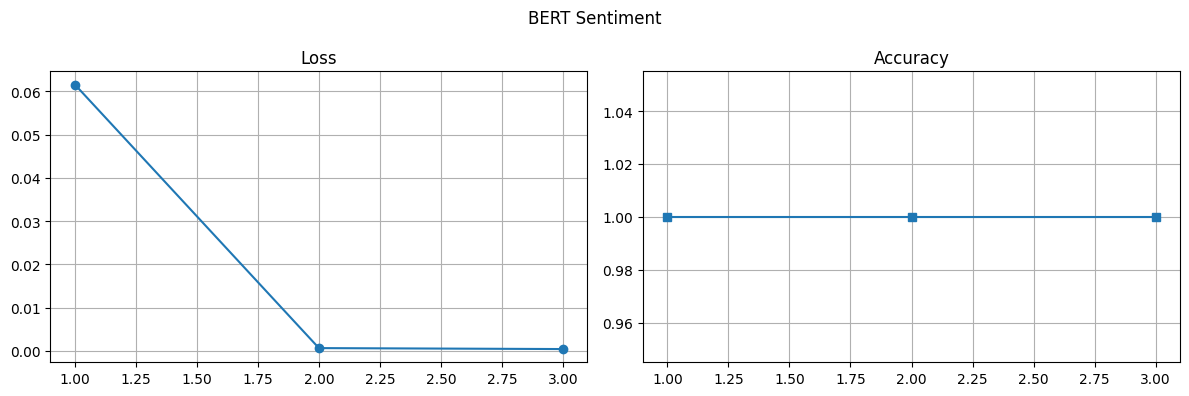

In [5]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep_r = range(1, EPOCHS_A+1)
axes[0].plot(ep_r, train_losses_a, marker='o'); axes[0].set_title('Loss');     axes[0].grid(True)
axes[1].plot(ep_r, test_accs_a,    marker='s'); axes[1].set_title('Accuracy'); axes[1].grid(True)
plt.suptitle('BERT Sentiment'); plt.tight_layout()
plt.savefig('lab7_partA.png', dpi=150); plt.show()

In [6]:
# PART B: BERT Question Answering (SQuAD)
# ================================================================
print("\n" + "="*60)
print("  PART B: BERT Question Answering (SQuAD)")
print("="*60)

squad      = load_dataset("squad")
SQUAD_N    = 1000
squad_data = squad['train'].select(range(SQUAD_N))

s = squad_data[0]
print(f"Context  : {s['context'][:100]}...")
print(f"Question : {s['question']}")
print(f"Answer   : {s['answers']['text'][0]}")

MAX_LEN_B = 384

class SQuADDataset(Dataset):
    def __init__(self, data):
        self.samples = []
        for ex in data:
            enc = tokenizer(
                ex['question'], ex['context'],
                max_length=MAX_LEN_B, truncation='only_second',
                padding='max_length', return_offsets_mapping=True,
                return_tensors='pt'
            )
            offset_map = enc.pop('offset_mapping')[0].tolist()
            seq_ids    = enc.sequence_ids(0)
            start_char = ex['answers']['answer_start'][0]
            end_char   = start_char + len(ex['answers']['text'][0])

            start_pos = end_pos = 0
            for idx, (s, e) in enumerate(offset_map):
                if seq_ids[idx] == 1:
                    if s <= start_char < e: start_pos = idx
                    if s < end_char <= e:   end_pos = idx; break

            self.samples.append({
                'input_ids':       enc['input_ids'][0],
                'attention_mask':  enc['attention_mask'][0],
                'token_type_ids':  enc['token_type_ids'][0],
                'start_positions': torch.tensor(start_pos),
                'end_positions':   torch.tensor(end_pos),
            })

    def __len__(self):        return len(self.samples)
    def __getitem__(self, i): return self.samples[i]



  PART B: BERT Question Answering (SQuAD)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Context  : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden...
Question : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer   : Saint Bernadette Soubirous


In [7]:
print("Building SQuAD dataset...")
squad_ds   = SQuADDataset(squad_data)
split      = int(0.9 * len(squad_ds))
train_dl_b = DataLoader(torch.utils.data.Subset(squad_ds, range(split)),        batch_size=8, shuffle=True)
val_dl_b   = DataLoader(torch.utils.data.Subset(squad_ds, range(split, len(squad_ds))), batch_size=8)

bert_qa = BertForQuestionAnswering.from_pretrained(MODEL_NAME).to(DEVICE)
for layer in bert_qa.bert.encoder.layer[:10]:
    for p in layer.parameters(): p.requires_grad = False

EPOCHS_B    = 3
optimizer_b = AdamW(filter(lambda p: p.requires_grad, bert_qa.parameters()),
                    lr=3e-5, weight_decay=0.01)
scheduler_b = get_linear_schedule_with_warmup(
    optimizer_b, num_warmup_steps=0,
    num_training_steps=len(train_dl_b) * EPOCHS_B
)


Building SQuAD dataset...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [9]:
train_losses_b, val_losses_b = [], []

print("\nTraining BERT QA...")
for epoch in range(EPOCHS_B):
    bert_qa.train()
    ep_loss = []
    for step, batch in enumerate(train_dl_b):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        loss  = bert_qa(**batch).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_qa.parameters(), 1.0)
        optimizer_b.step(); scheduler_b.step(); optimizer_b.zero_grad()
        ep_loss.append(loss.item())
        if step % 20 == 0:
            print(f"  Epoch {epoch+1} Step {step:3d} | loss: {loss.item():.4f}")

    bert_qa.eval()
    vl = []
    with torch.no_grad():
        for batch in val_dl_b:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            vl.append(bert_qa(**batch).loss.item())

    train_losses_b.append(np.mean(ep_loss))
    val_losses_b.append(np.mean(vl))
    print(f"Epoch {epoch+1}/{EPOCHS_B} | train: {np.mean(ep_loss):.4f} | val: {np.mean(vl):.4f}")



Training BERT QA...
  Epoch 1 Step   0 | loss: 5.1349
  Epoch 1 Step  20 | loss: 4.4897
  Epoch 1 Step  40 | loss: 4.2935
  Epoch 1 Step  60 | loss: 4.6355
  Epoch 1 Step  80 | loss: 3.7651
  Epoch 1 Step 100 | loss: 4.0680
Epoch 1/3 | train: 4.2520 | val: 3.7631
  Epoch 2 Step   0 | loss: 3.5873
  Epoch 2 Step  20 | loss: 2.4121
  Epoch 2 Step  40 | loss: 3.2961
  Epoch 2 Step  60 | loss: 4.1900
  Epoch 2 Step  80 | loss: 2.9745
  Epoch 2 Step 100 | loss: 3.1059
Epoch 2/3 | train: 3.3028 | val: 3.5352
  Epoch 3 Step   0 | loss: 2.5781
  Epoch 3 Step  20 | loss: 3.4145
  Epoch 3 Step  40 | loss: 3.1398
  Epoch 3 Step  60 | loss: 3.7459
  Epoch 3 Step  80 | loss: 2.5355
  Epoch 3 Step 100 | loss: 2.3849
Epoch 3/3 | train: 2.9893 | val: 3.5041


In [10]:
def answer_question(question, context):
    bert_qa.eval()
    enc = tokenizer(question, context, max_length=MAX_LEN_B,
                    truncation='only_second', padding='max_length',
                    return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = bert_qa(**enc)
    start = torch.argmax(out.start_logits, dim=-1).item()
    end   = torch.argmax(out.end_logits,   dim=-1).item()
    if end < start: end = start + 5
    return tokenizer.decode(enc['input_ids'][0][start:end+1], skip_special_tokens=True)

qa_pairs = [
    {"context": "TensorFlow is an open-source ML framework developed by Google Brain team. Released in 2015.",
     "question": "Who developed TensorFlow?"},
    {"context": "The Eiffel Tower is in Paris, France. Constructed from 1887 to 1889.",
     "question": "When was the Eiffel Tower built?"},
    {"context": "BERT stands for Bidirectional Encoder Representations from Transformers. Introduced by Google in 2018.",
     "question": "What does BERT stand for?"},
    {"context": "Python was created by Guido van Rossum and first released in 1991.",
     "question": "Who created Python?"},
]


--- BERT QA Predictions ---

  Q: Who developed TensorFlow?
  A: google brain team. released in

  Q: When was the Eiffel Tower built?
  A: 1889

  Q: What does BERT stand for?
  A: bert stands for bidirectional encoder representations from transformers. introduced by google

  Q: Who created Python?
  A: 1991


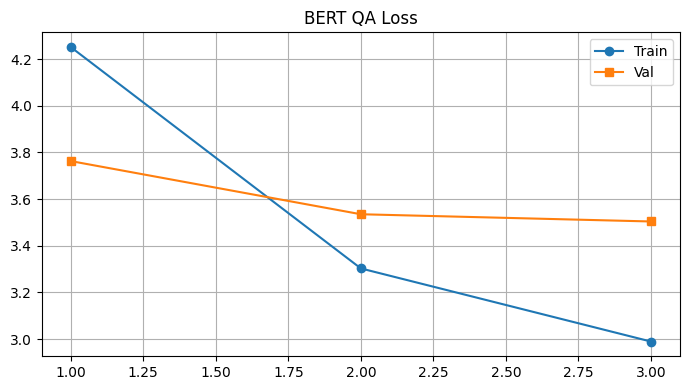

In [11]:
print("\n--- BERT QA Predictions ---")
for pair in qa_pairs:
    print(f"\n  Q: {pair['question']}")
    print(f"  A: {answer_question(pair['question'], pair['context'])}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS_B+1), train_losses_b, marker='o', label='Train')
ax.plot(range(1, EPOCHS_B+1), val_losses_b,   marker='s', label='Val')
ax.set_title('BERT QA Loss'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('lab7_partB.png', dpi=150); plt.show()
